In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
new = pd.read_excel('data/_sufficiency_data.xlsx')
print(len(new))
new.sample(3)

143


,Year,Value,Innovation Name,Indicator Number,Indicator Name,Description,Metric,Data Source,Comments,Spatial Scale
59,1967,0.0,prosperity indicators (non-GDP),3.3,Risk & Uncertainty (Shared Expectations),scientific publications on demand-responsive p...,# publications,Web of Science,Web of Science search query adapted from 10.11...,Global
100,2008,284.0,prosperity indicators (non-GDP),3.3,Risk & Uncertainty (Shared Expectations),scientific publications on demand-responsive p...,# publications,Web of Science,Web of Science search query adapted from 10.11...,Global
105,2013,507.0,prosperity indicators (non-GDP),3.3,Risk & Uncertainty (Shared Expectations),scientific publications on demand-responsive p...,# publications,Web of Science,Web of Science search query adapted from 10.11...,Global


4


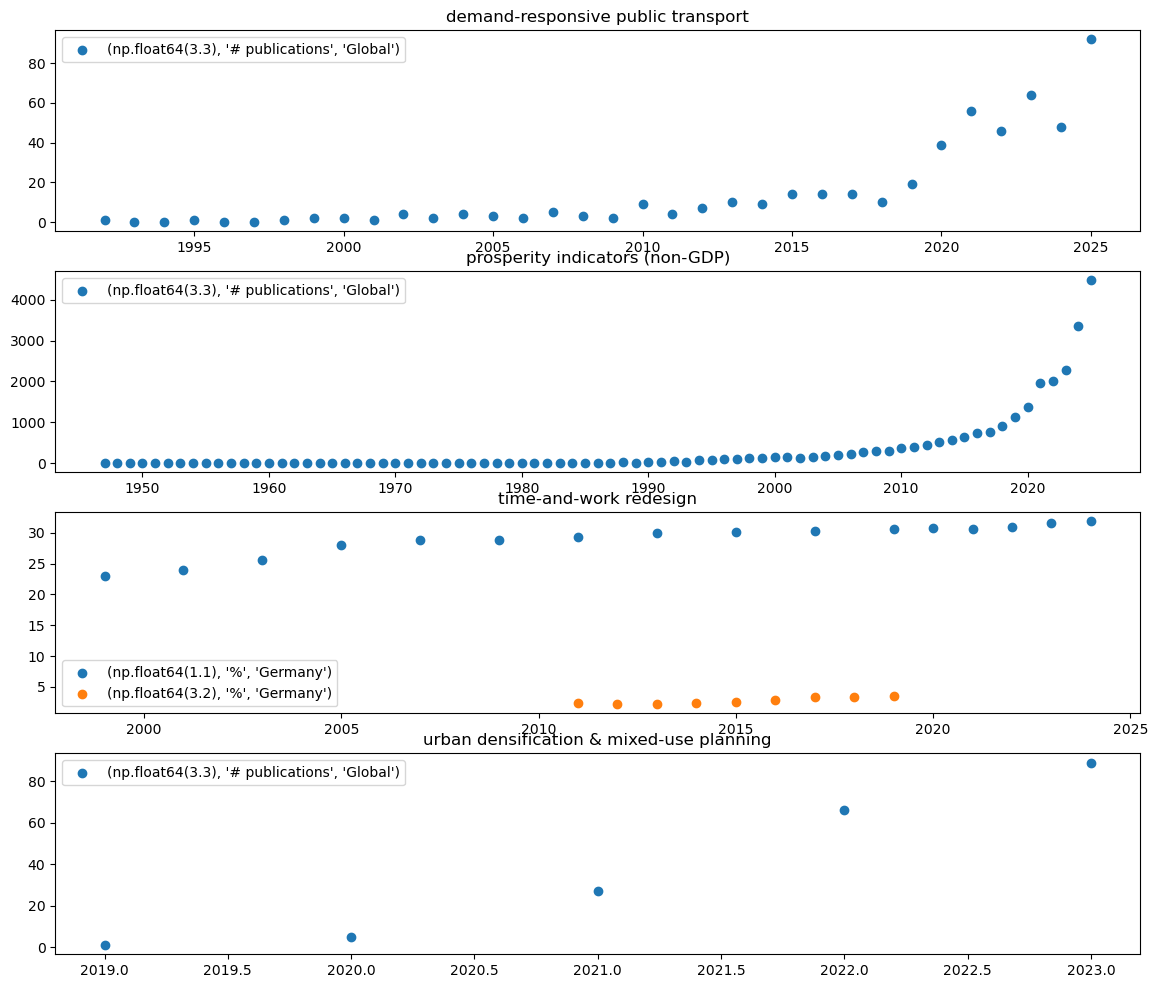

In [3]:
innos = new.groupby('Innovation Name')
print(len(innos))
fix, axs = plt.subplots(nrows=len(innos), figsize=(14,3*len(innos)))
for (name, inno), ax in zip({i[0]:i[1] for i in list(innos)}.items(), axs):
    g = inno.groupby(['Indicator Number', 'Metric', 'Spatial Scale'])
    i = 0
    if len(g) > 5: name += ' (sample, 5 out of {})'.format(len(g))
    for ts_name, ts in {i[0]:i[1] for i in list(g)}.items():
        ax.scatter(x=ts['Year'], y=ts['Value'], label=ts_name)
        i += 1
        if i > 5: break
    ax.legend()
    ax.set_title(name)

In [2]:
old = pd.read_csv('data/adjusted_datasets_v30_Lynn.csv').drop('Unnamed: 0', axis=1, errors='ignore')
len(old)
old.sample()

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_15104\3786050156.py:1: DtypeWarning: Columns (1,11) have mixed types. Specify dtype option on import or set low_memory=False.
  old = pd.read_csv('data/adjusted_datasets_v30_Lynn.csv').drop('Unnamed: 0', axis=1, errors='ignore')


,Year,Value,Innovation Name,Indicator Number,Indicator Name,Description,Metric,Data Source,Comments,Spatial Scale,File,Sheet
30445,2004,3,organic food,3.5,Market Formation,Partial up to max CumulativeStartups,Partial up to max cum. # companies,Pitchbook,Pitchbook,Japan,/Users/dani/Energy Emissions/Priorities Attemp...,organic food consumption


In [10]:
merged = pd.concat([old, new]).reset_index(drop=True)
missing = merged.loc[merged[[c for c in merged.columns if not c in ['Data Source', 'Comments', 'File', 'Sheet']]].isna().any(axis=1)]
len(missing)

152

In [11]:
missing.groupby(['Innovation Name', 'Indicator Number', 'Metric', 'Spatial Scale'])['Year'].count()

Innovation Name      Indicator Number  Metric        Spatial Scale               
car sharing          1.1               market share  Germany                          1
co-housing           1.1               market share  Canton de Vaud (Switzerland)    12
firm ESG reporting   1.1               market share  Africa                          14
                                                     Asia                            17
                                                     LatinAmericaCarib               15
                                                     North America                   17
                                                     Oceania                         13
                                                     global                          18
passive buildings    1.1               market share  Austria                          1
                                                     Global                          34
reducing food waste  1.1              

In [16]:
merged.to_csv('data/adjusted_datasets_v29.csv', index=False)